# 16S phylogeny: MAFFT → FastTree → Faith PD + UniFrac

Build a phylogenetic tree from ASV centroids and unlock the tree-aware
diversity metrics (Faith's PD, weighted / unweighted UniFrac) that the
plain 16S tutorial couldn't run.

**Pipeline (all real tool wrappers in `ov.alignment`):**

| Step | Tool | Function |
|---|---|---|
| 1 | MAFFT `--auto` | `ov.alignment.mafft` — multiple sequence alignment |
| 2 | FastTree / FastTreeMP | `ov.alignment.fasttree` — approximately-ML tree |
| — | both as one call | `ov.alignment.build_phylogeny` |

**Downstream (in `ov.micro`):**

- `ov.micro.attach_tree(adata, newick=...)` — store tree on `adata.uns['tree']`, prune to `var_names`
- `ov.micro.Alpha(adata).run(['faith_pd', ...])` — tree-aware alpha diversity
- `ov.micro.Beta(adata).run(metric='unweighted_unifrac' / 'weighted_unifrac')`
- `ov.micro.Ordinate(adata, dist_key='unweighted_unifrac').pcoa(n=3)`

> **No `$HOME` writes.** All intermediates land under the `workdir` path you pass explicitly.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

import omicverse as ov
ov.plot_set()

# Load the AnnData produced by the basic 16S tutorial
BASE = Path('/scratch/users/steorra/analysis/omicverse_dev/cache/16s')
H5AD = BASE / 'run_mothur_sop' / 'mothur_sop_16s.h5ad'
ASVS = BASE / 'run_mothur_sop' / 'asv' / 'asvs.fasta'
WORK = BASE / 'phylogeny_tutorial'
WORK.mkdir(parents=True, exist_ok=True)

adata = ad.read_h5ad(H5AD)
print('adata:', adata.shape)
print('var has taxonomy cols:', [c for c in adata.var.columns if c in ('phylum','genus')])

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

adata: (20, 598)
var has taxonomy cols: ['phylum', 'genus']


## 2. Build the phylogenetic tree

MAFFT aligns all 598 ASV centroids, then FastTree(MP) infers the tree.
~4 seconds on 8 CPU.

In [2]:
tree = ov.alignment.build_phylogeny(
    str(ASVS),
    workdir=str(WORK),
    mafft_threads=8,
    fasttree_threads=4,
)
print('aligned:', tree['aligned'])
print('tree   :', tree['tree'])
print('newick (first 120 chars):', tree['newick'][:120])

>> /home/users/steorra/miniforge3/envs/omicverse/bin/mafft --thread 8 --auto /scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop/asv/asvs.fasta


>> /home/users/steorra/miniforge3/envs/omicverse/bin/FastTreeMP -nt -gtr -gamma /scratch/users/steorra/analysis/omicverse_dev/cache/16s/phylogeny_tutorial/aligned/aligned.fasta


aligned: /scratch/users/steorra/analysis/omicverse_dev/cache/16s/phylogeny_tutorial/aligned/aligned.fasta
tree   : /scratch/users/steorra/analysis/omicverse_dev/cache/16s/phylogeny_tutorial/tree/tree.nwk
newick (first 120 chars): (((((F3D0.1908:0.019502580,(F3D0.682:0.000000006,F3D0.908:0.004693323)0.000:0.000000006)0.957:0.025586231,((F3D0.4522:0.


## 3. Attach the tree to AnnData

`attach_tree` prunes tips to `var_names`, midpoint-roots the tree (FastTree
emits unrooted), and writes the newick to `adata.uns['tree']`.

In [3]:
ov.micro.attach_tree(adata, newick=tree['newick'])
print("uns['tree'] len:", len(adata.uns['tree']))
print("tree_tips    :", adata.uns['micro']['tree_tips'])

uns['tree'] len: 21046
tree_tips    : 598


## 4. Phylogenetic alpha: Faith PD

Faith's Phylogenetic Diversity = the **total branch length** of the
subtree spanned by a sample's observed ASVs. Unlike Observed / Shannon
(which count ASVs agnostically), Faith PD rewards samples whose ASVs are
spread across the tree.

In [4]:
import re
# rebuild day + group metadata (not always round-tripped through h5ad)
for name in adata.obs_names:
    m = re.match(r'F3D(\d+)', name)
    day = int(m.group(1)) if m else -1
    group = 'Early' if m and day <= 9 else ('Late' if m else 'Mock')
    adata.obs.loc[name, 'day'] = day
    adata.obs.loc[name, 'group'] = group
adata.obs['day'] = adata.obs['day'].astype(int)

alpha = ov.micro.Alpha(adata).run(metrics=['shannon', 'observed_otus', 'faith_pd'])
alpha.describe()

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/skbio/util/_warning.py:40: FutureWarning: The default behavior of `root_at_midpoint` is subject to change in 0.7.0. The new default behavior can be achieved by specifying `reset=True, branch_attrs=[], root_name=None`.
  warn(message, warning)
/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


         shannon  observed_otus   faith_pd
count  20.000000      20.000000  20.000000
mean    3.880857     280.800000  15.060490
std     0.362040      73.562433   2.608692
min     2.830575      38.000000   5.385063
25%     3.731984     253.000000  14.484808
50%     3.901867     283.000000  15.001241
75%     4.186014     315.250000  16.445646
max     4.348582     384.000000  17.822771

/tmp/ipykernel_2035/3832780310.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)
/tmp/ipykernel_2035/3832780310.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)
/tmp/ipykernel_2035/3832780310.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)


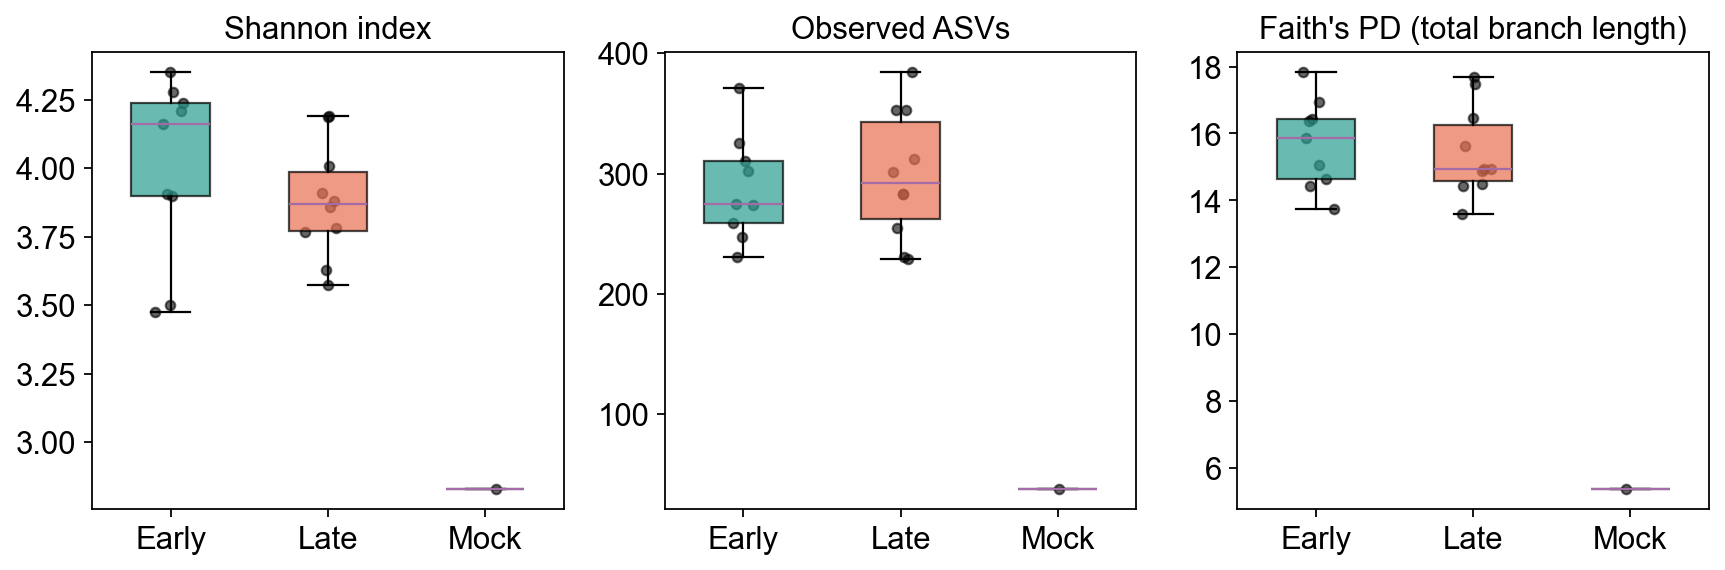

In [5]:
# Compare the three alpha metrics across Early / Late / Mock
palette = {'Early': '#2a9d8f', 'Late': '#e76f51', 'Mock': '#264653'}
groups = ['Early', 'Late', 'Mock']

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, metric, ylabel in zip(
    axes,
    ['shannon', 'observed_otus', 'faith_pd'],
    ['Shannon index', 'Observed ASVs', "Faith's PD (total branch length)"],
):
    data = [adata.obs[adata.obs.group == g][metric].dropna().values for g in groups]
    bp = ax.boxplot(data, labels=groups, patch_artist=True, widths=0.5, showfliers=False)
    for patch, g in zip(bp['boxes'], groups):
        patch.set_facecolor(palette[g]); patch.set_alpha(0.7)
    for i, (g, vals) in enumerate(zip(groups, data), start=1):
        x = np.random.normal(i, 0.05, size=len(vals))
        ax.scatter(x, vals, color='k', alpha=0.6, s=18)
    ax.set_title(ylabel)
plt.tight_layout()
plt.show()

## 5. Phylogenetic beta: UniFrac

UniFrac = the **fraction of branch length** unique to one of two samples.
- **Unweighted**: presence/absence only — emphasises rare taxa
- **Weighted**: weighted by abundance — emphasises dominant taxa

Both are stored into `adata.obsp`.

In [6]:
b = ov.micro.Beta(adata)
b.run(metric='unweighted_unifrac', rarefy=False)
b.run(metric='weighted_unifrac', rarefy=False)

uu = adata.obsp['unweighted_unifrac']
wu = adata.obsp['weighted_unifrac']
triu = np.triu_indices_from(uu, k=1)
print(f"unweighted UniFrac: mean off-diag = {uu[triu].mean():.3f}")
print(f"weighted UniFrac  : mean off-diag = {wu[triu].mean():.3f}")

unweighted UniFrac: mean off-diag = 0.362
weighted UniFrac  : mean off-diag = 0.222


## 6. Compare ordinations: Bray-Curtis vs UniFrac

Ordinate each of the three distance matrices with PCoA. If the
phylogenetic structure carries additional signal, UniFrac PCoA should
separate Early vs Late even more clearly than Bray-Curtis did.

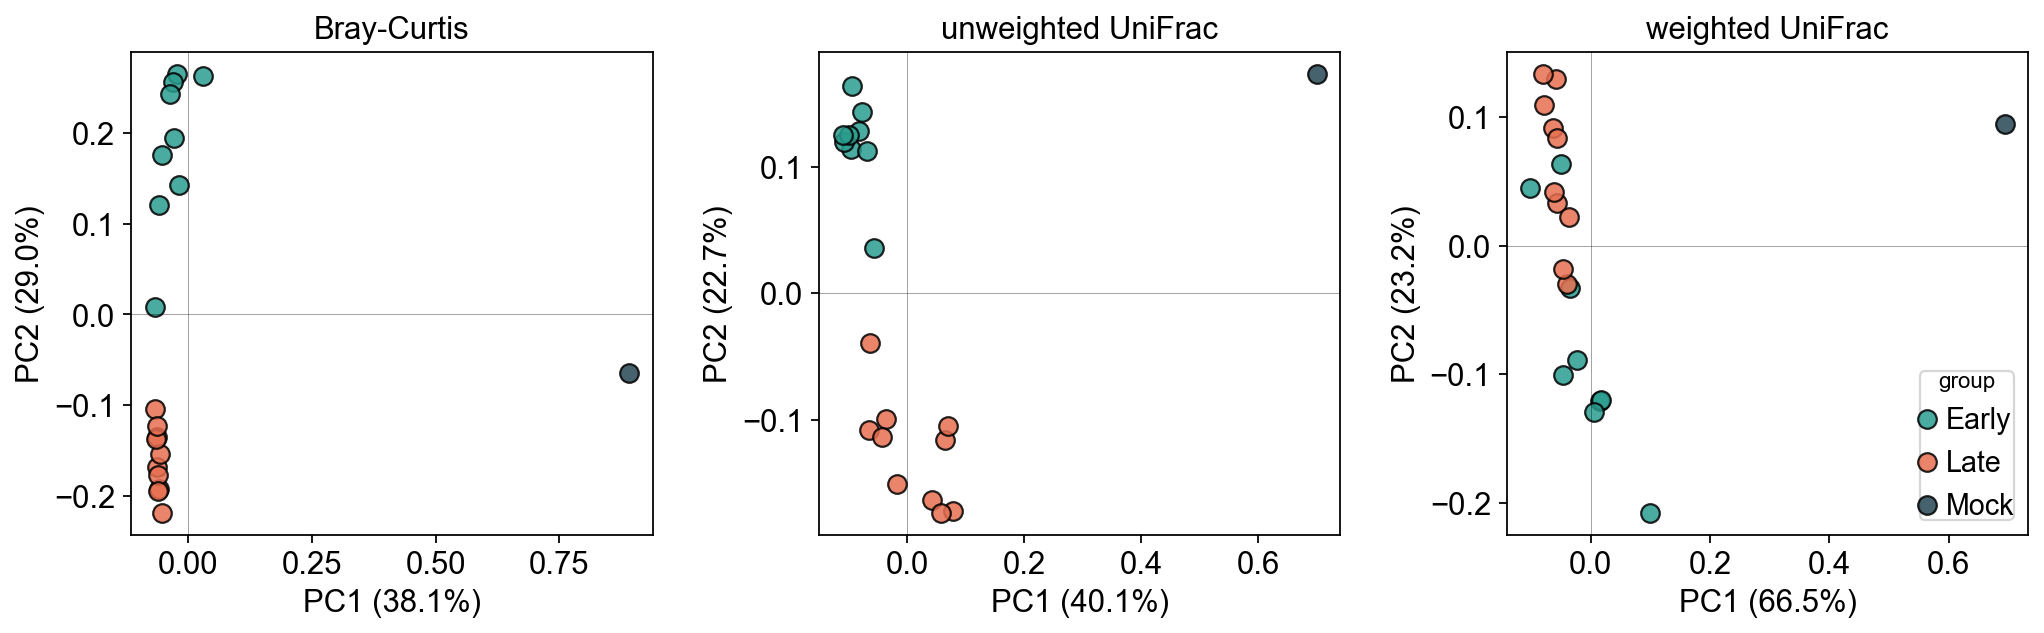

In [7]:
# Bray-Curtis as a baseline
b.run(metric='braycurtis', rarefy=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, dist_key, title in zip(
    axes,
    ['braycurtis', 'unweighted_unifrac', 'weighted_unifrac'],
    ['Bray-Curtis', 'unweighted UniFrac', 'weighted UniFrac'],
):
    ord_ = ov.micro.Ordinate(adata, dist_key=dist_key)
    ord_.pcoa(n=2)
    pct = ord_.proportion_explained() * 100.0
    coords = pd.DataFrame(adata.obsm[f'{dist_key}_pcoa'],
                          index=adata.obs_names, columns=['PC1','PC2'])
    for g in groups:
        sub = adata.obs[adata.obs.group == g]
        if sub.empty: continue
        ax.scatter(coords.loc[sub.index, 'PC1'],
                   coords.loc[sub.index, 'PC2'],
                   color=palette[g], s=70, alpha=0.85,
                   edgecolor='k', label=g)
    ax.set_xlabel(f'PC1 ({pct[0]:.1f}%)')
    ax.set_ylabel(f'PC2 ({pct[1]:.1f}%)')
    ax.set_title(title)
    ax.axhline(0, color='k', lw=0.4, alpha=0.4)
    ax.axvline(0, color='k', lw=0.4, alpha=0.4)
axes[-1].legend(title='group', loc='best', frameon=True)
plt.tight_layout()
plt.show()

## 7. Save the tree-enriched AnnData

In [8]:
out = BASE / 'run_mothur_sop' / 'mothur_sop_16s_tree.h5ad'
adata.write_h5ad(out)
print('saved', out, '-', out.stat().st_size // 1024, 'KB')

saved /scratch/users/steorra/analysis/omicverse_dev/cache/16s/run_mothur_sop/mothur_sop_16s_tree.h5ad - 455 KB


## Notes

- **Rooting**. FastTree produces an unrooted tree; `_tree_object` midpoint-roots
  it before passing to scikit-bio's Faith PD / UniFrac, which require rooted
  input. Midpoint rooting is neutral wrt outgroup choice and is the canonical
  choice for ASV trees.
- **SEPP alternative**. For a phylogenetically-accurate tree (insertion into
  a reference backbone), QIIME 2's SEPP plugin is the gold standard. That's
  a follow-up notebook — `ov.alignment.build_phylogeny` is the
  novo-from-ASVs path.
- **Rarefaction**. UniFrac is less sensitive to library-size differences
  than Bray-Curtis, which is why we pass `rarefy=False` by default here.
  Pass `rarefy=True` for the strictest comparison.